In [1]:
import pandas as pd
import glob
import json
import os

sample_path = f'{os.getcwd()}/../workspace/samples/'

x86_samples = 'x86-gemini-pro'
arm_samples = 'arm-gemini-pro'

def get_rows(path):

    summaries = sorted(glob.glob(f'{path}/*/agent_repair/summary.json'))

    rows = []
    for sample, path in enumerate(summaries):

        with open(path, 'r') as f:
            data = json.load(f)
        
        arch = data['summary']['arch']
        model = data['models']['llm']

        for attempt in data['attempts']:
            rows.append({
            'sample': sample,
            'arch': arch,
            'model': model,
            'attempt': attempt['attempt'],
            'boot_succeeded': attempt['summary']['boot_succeeded'],
            'define': attempt['changes']['define'],
            'undefine': attempt['changes']['undefine'],
            'original_config': f'{os.path.dirname(path)}/../.config',
            'modified_config': f'{os.path.dirname(path)}/attempt_{attempt["attempt"]}/modified.config',
            'edit_distance': data['summary']['edit_distance'],
            'total_constraints': data['summary']['total_constraints'],
            'define': attempt['changes']['define'],
            'undefine': attempt['changes']['undefine'],
        })

    return rows

rows = get_rows(f'{sample_path}/{x86_samples}') + get_rows(f'{sample_path}/{arm_samples}')
df = pd.DataFrame(rows)

print(df.groupby('model')['sample'].nunique())

df.head()

model
gemini-3.1-pro-preview    50
Name: sample, dtype: int64


,sample,arch,model,attempt,boot_succeeded,define,undefine,original_config,modified_config,edit_distance,total_constraints
0,0,x86_64,gemini-3.1-pro-preview,0,no,None,None,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,2629,79
1,0,x86_64,gemini-3.1-pro-preview,1,timeout,[],[CONFIG_KASAN],/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,2629,79
2,0,x86_64,gemini-3.1-pro-preview,2,panic,"[CONFIG_TTY, CONFIG_SERIAL_8250, CONFIG_SERIAL...",[CONFIG_KASAN],/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,2629,79
3,0,x86_64,gemini-3.1-pro-preview,3,timeout,[],"[CONFIG_KASAN, CONFIG_KCSAN]",/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,2629,79
4,0,x86_64,gemini-3.1-pro-preview,4,panic,"[CONFIG_TTY, CONFIG_SERIAL_8250, CONFIG_SERIAL...","[CONFIG_KASAN, CONFIG_KCSAN]",/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,/Users/ryangarfinkel/Documents/UCF/Thesis/KBoo...,2629,79


In [2]:
def parse_config(path):
    with open(path, 'r') as f:
        lines = f.readlines()

    options = set()

    for line in lines:
        if '=' in line:
            options.add(line.strip().split('=')[0])
            
    return options

def jaccard_similarity(a, b):
    return len(a & b) / len(a | b) if a | b else 1.0

In [3]:
last_attempts = df[df['boot_succeeded'] == 'yes'].copy()

last_attempts['before_after_similarity'] = last_attempts.apply(lambda row: jaccard_similarity(
    parse_config(row['original_config']),
    parse_config(row['modified_config'])
), axis=1)

last_attempts['num_defines'] = last_attempts['define'].apply(len)
last_attempts['num_undefines'] = last_attempts['undefine'].apply(len)
last_attempts['total_changes'] = last_attempts['num_defines'] + last_attempts['num_undefines']

print('x86 Before-After Similarity:')
print(last_attempts[last_attempts['arch'] == 'x86_64'][['before_after_similarity', 'edit_distance', 'num_defines', 'num_undefines', 'total_changes']].describe().to_string())

print('\n\nARM Before-After Similarity:')
print(last_attempts[last_attempts['arch'] == 'arm64'][['before_after_similarity', 'edit_distance', 'num_defines', 'num_undefines', 'total_changes']].describe().to_string())

print('\n\nOverall Before-After Similarity:')
print(last_attempts[['before_after_similarity', 'edit_distance', 'num_defines', 'num_undefines', 'total_changes']].describe().to_string())

x86 Before-After Similarity:
       before_after_similarity  edit_distance  num_defines  num_undefines  total_changes
count                45.000000      45.000000    45.000000      45.000000      45.000000
mean                  0.851343    2495.955556    32.622222      24.933333      57.555556
std                   0.088025    1261.352520    18.113642      17.000535      28.936887
min                   0.613361     257.000000     5.000000       1.000000      12.000000
25%                   0.826946    1663.000000    19.000000      11.000000      33.000000
50%                   0.852813    2253.000000    29.000000      21.000000      53.000000
75%                   0.913010    3568.000000    39.000000      37.000000      76.000000
max                   0.986170    5671.000000    97.000000      69.000000     140.000000


ARM Before-After Similarity:
       before_after_similarity  edit_distance  num_defines  num_undefines  total_changes
count                47.000000      47.000000    4

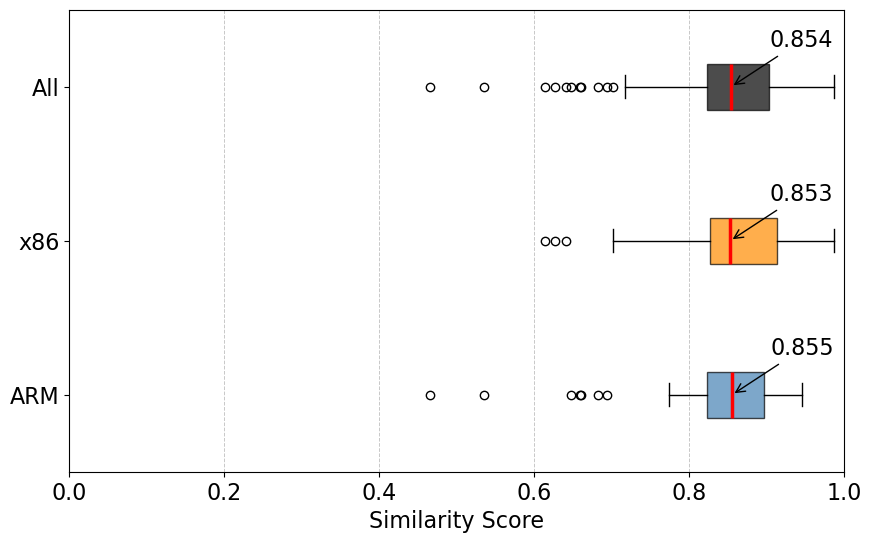

In [4]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))                                   

before_after_similarity_data = [
    last_attempts[last_attempts['arch'] == 'arm64']['before_after_similarity'],
    last_attempts[last_attempts['arch'] == 'x86_64']['before_after_similarity'],
    last_attempts['before_after_similarity'],
]

bp = ax.boxplot(before_after_similarity_data, labels=['ARM', 'x86', 'All'], patch_artist=True, vert=False)

for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange', 'black']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, median in enumerate(bp['medians']):
    median.set_color('red')
    median.set_linewidth(2.5)
    x = median.get_xdata()[1]
    y = i + 1
    ax.annotate(f'{x:.3f}', xy=(x, y), xytext=(x + 0.05, y + 0.3), fontsize=16, color='black', va='center', arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Similarity Score', fontsize=16)
ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(0, 1)

plt.savefig('preservation.pdf', format='pdf', bbox_inches='tight')
plt.show()